# Phase 4 — Exploratory Data Analysis

This notebook tells a question-driven descriptive story for financial inclusion and mobile-money adoption. Weighted rates use the supplied survey weight; respondent counts remain unweighted. No hypothesis tests, models, or causal claims are included.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').is_file())
sys.path.insert(0, str(project_root / 'src'))

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from finaccess_eswatini.phase4_eda import run

summary = run()
report_dir = project_root / 'reports' / 'phase_4'
overall = pd.read_csv(report_dir / 'overall_rates.csv')
subgroup = pd.read_csv(report_dir / 'subgroup_rates.csv')
print('Respondents:', summary['source_validation']['rows'])
print(overall[['outcome', 'weighted_rate', 'unweighted_rate', 'positive_count']].to_string(index=False))

Respondents: 1051
                      outcome  weighted_rate  unweighted_rate  positive_count
Financial institution account       0.431356         0.510942             537
         Mobile money account       0.504069         0.581351             611


## How common are the outcomes?

The chart distinguishes population-oriented weighted estimates from raw sample proportions.

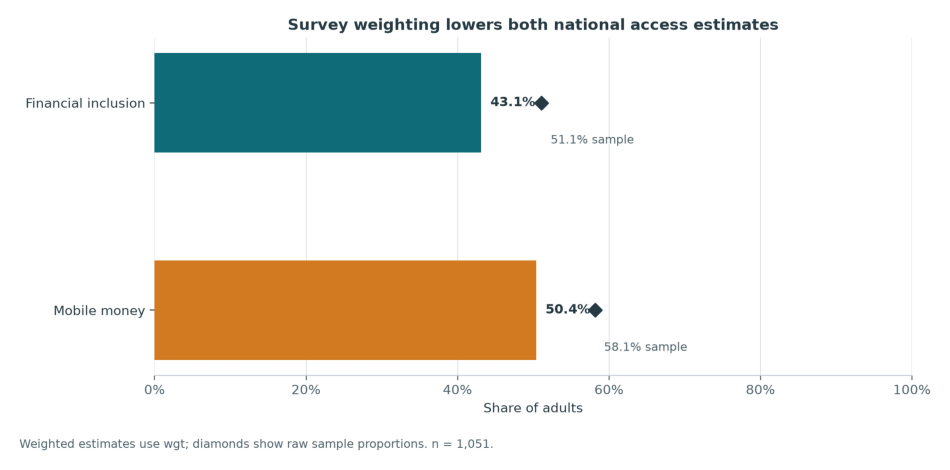

In [2]:
image = mpimg.imread(report_dir / 'figures' / '01_overall_access_rates.png')
plt.figure(figsize=(12, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Do demographic and socioeconomic characteristics align with access?

Age, education, income quintile, and workforce status are compared for both outcomes. These are descriptive associations, not adjusted effects.

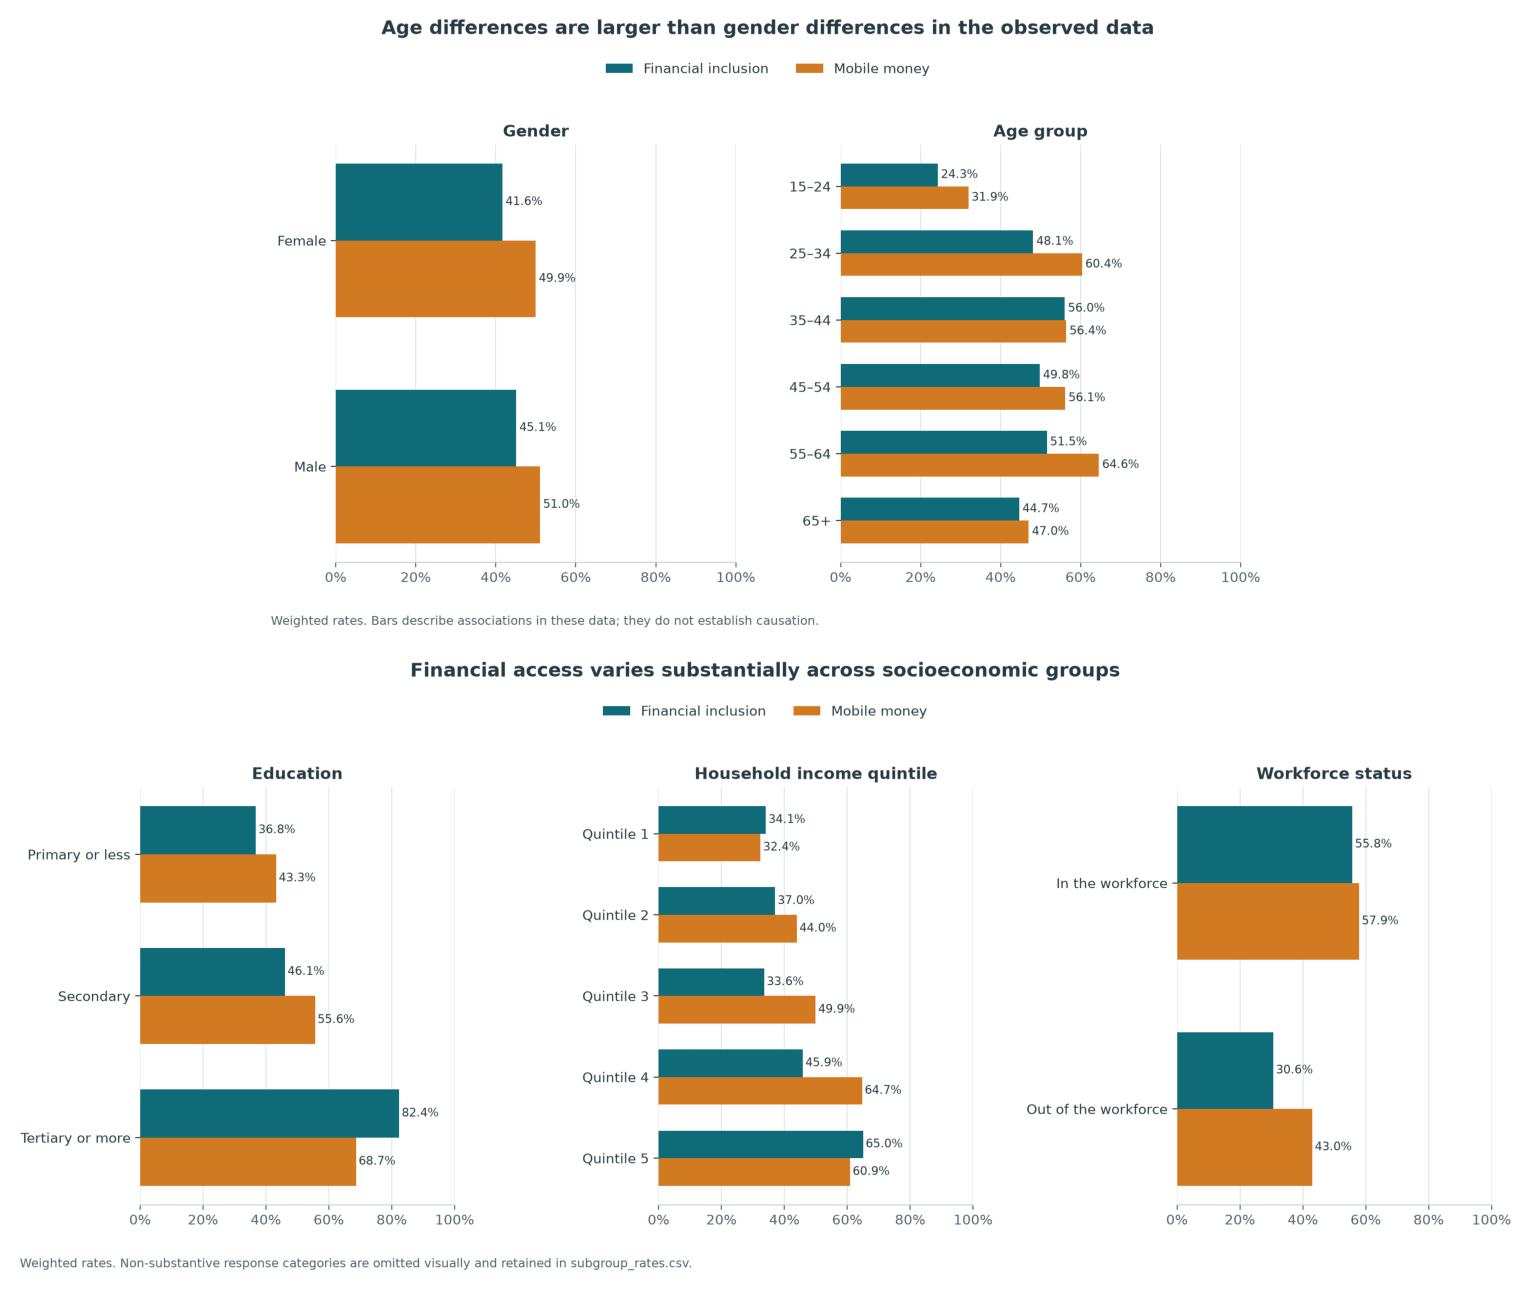

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 13))
for ax, filename in zip(axes, ['02_demographic_patterns.png', '03_socioeconomic_patterns.png']):
    ax.imshow(mpimg.imread(report_dir / 'figures' / filename))
    ax.axis('off')
plt.tight_layout()
plt.show()

## How do internet and phone access relate to the outcomes?

Digital-access comparisons use the exact Phase 3 categories, including the source limitation that `internet_use=0` combines no, don't know, and refused.

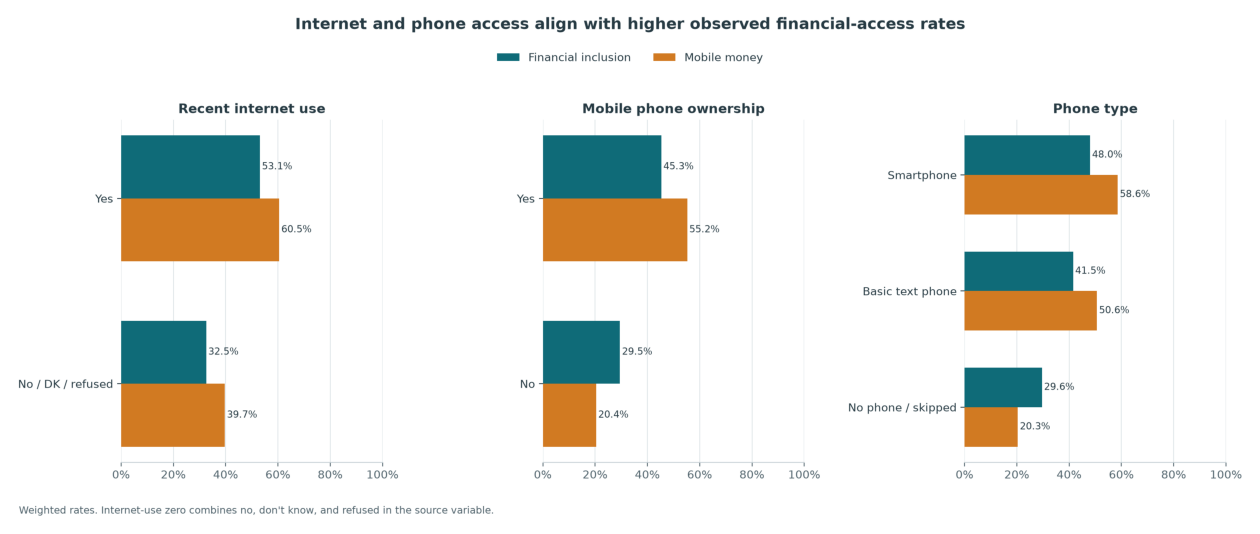

• The weighted financial-inclusion estimate is 43.1%; the weighted mobile-money estimate is 50.4%.
• Financial inclusion is 82.4% among respondents with tertiary education or more and 36.8% among those with primary education or less.
• Financial inclusion rises from 34.1% in quintile 1 to 65.0% in quintile 5.
• Financial inclusion is 55.8% in the workforce and 30.6% outside it.
• Mobile-money adoption is 60.5% among recent internet users and 39.7% in the combined zero category.
• Mobile-money adoption is 55.2% among phone owners and 20.4% among respondents reporting no phone.


In [4]:
image = mpimg.imread(report_dir / 'figures' / '04_digital_access_patterns.png')
plt.figure(figsize=(16, 7))
plt.imshow(image)
plt.axis('off')
plt.show()

for finding in summary['findings']:
    print(f"• {finding['finding']}")

## Guardrails

Urban/rural analysis is unavailable because `urbanicity` is constant. Formal tests and effect sizes are reserved for Phase 5. Full results and limitations are recorded in `reports/phase_4/eda_report.md`.